In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✓ Libraries loaded!")

✓ Libraries loaded!


In [2]:
# Load the results
df = pd.read_csv("../results/master_thesis_table.csv")

# Display the table
print("MASTER THESIS RESULTS TABLE")
print("="*80)
display(df)

# Quick stats
print(f"\nTotal models evaluated: {len(df)}")
print(f"Best F1-Score: {df.loc[df['F1'].idxmax(), 'Model']} ({df['F1'].max()})")
print(f"Fastest Model: {df.loc[df['Time/pkt (ms)'].idxmin(), 'Model']} ({df['Time/pkt (ms)'].min()} ms)")
print(f"Smallest Model: {df.loc[df['Size (MB)'].idxmin(), 'Model']} ({df['Size (MB)'].min()} MB)")

MASTER THESIS RESULTS TABLE


,Model,Accuracy,Precision,Recall,F1,Specificity,FPR,AUC,Size (MB),Time/pkt (ms)
0,Stacking A (Top 3),0.9658,0.9620,0.9494,0.9557,0.9762,0.0238,0.9940,40.82,0.0526
1,Stacking B (All 5),0.9658,0.9620,0.9494,0.9557,0.9762,0.0238,0.9939,105.03,0.5138
2,Random Forest,0.9652,0.9665,0.9432,0.9547,0.9792,0.0208,0.9938,40.65,0.0137
3,Soft Voting,0.9636,0.9616,0.9441,0.9528,0.9760,0.0240,0.9927,40.81,0.0917
4,Hard Voting,0.9612,0.9600,0.9393,0.9495,0.9751,0.0249,NaN,104.98,0.4162
5,Gradient Boosting,0.9501,0.9407,0.9303,0.9355,0.9627,0.0373,0.9885,0.13,0.0044
6,KNN,0.9153,0.9267,0.8491,0.8862,0.9573,0.0427,0.9650,64.20,0.3861
7,AdaBoost,0.8936,0.8741,0.8482,0.8610,0.9224,0.0776,0.9654,0.03,0.0605
8,Naive Bayes,0.6804,0.9987,0.1778,0.3018,0.9999,0.0001,0.6000,0.01,0.0075



Total models evaluated: 9
Best F1-Score: Stacking A (Top 3) (0.9557)
Fastest Model: Gradient Boosting (0.0044 ms)
Smallest Model: Naive Bayes (0.01 MB)


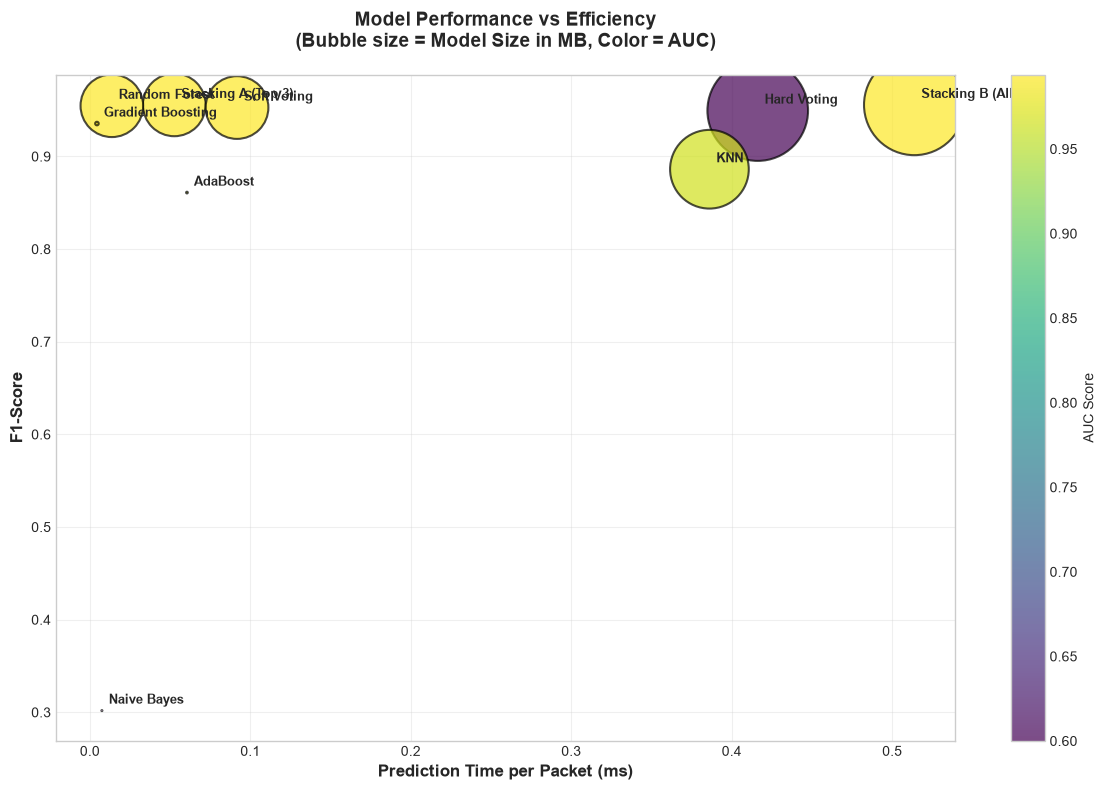

✓ Plot saved to ../results/f1_vs_time.png


In [3]:
plt.figure(figsize=(12, 8))

# scatter plot
scatter = plt.scatter(df['Time/pkt (ms)'], df['F1'], 
                      s=df['Size (MB)']*50,  # Size represents model size
                      c=df['AUC'].fillna(0.6), 
                      cmap='viridis', 
                      alpha=0.7, 
                      edgecolors='black', 
                      linewidth=1.5)

# labels for each model
for i, row in df.iterrows():
    plt.annotate(row['Model'], 
                 (row['Time/pkt (ms)'], row['F1']), 
                 xytext=(5, 5), 
                 textcoords='offset points',
                 fontsize=9,
                 fontweight='bold')

plt.xlabel('Prediction Time per Packet (ms)', fontsize=12, fontweight='bold')
plt.ylabel('F1-Score', fontsize=12, fontweight='bold')
plt.title('Model Performance vs Efficiency\n(Bubble size = Model Size in MB, Color = AUC)', 
          fontsize=14, fontweight='bold', pad=20)
plt.colorbar(scatter, label='AUC Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('../results/f1_vs_time.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved to ../results/f1_vs_time.png")

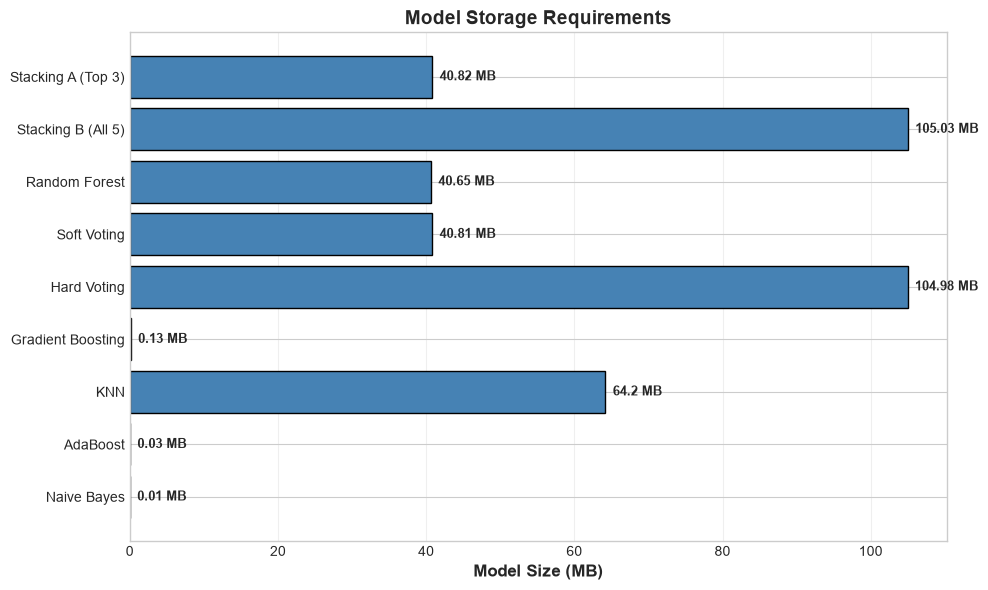

✓ Plot saved to ../results/model_sizes.png


In [4]:
plt.figure(figsize=(10, 6))

# horizontal bar chart
bars = plt.barh(df['Model'], df['Size (MB)'], color='steelblue', edgecolor='black')

# Add value labels on bars
for bar, size in zip(bars, df['Size (MB)']):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
             f'{size} MB', va='center', fontsize=9, fontweight='bold')

plt.xlabel('Model Size (MB)', fontsize=12, fontweight='bold')
plt.title('Model Storage Requirements', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Best model at top
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

plt.savefig('../results/model_sizes.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved to ../results/model_sizes.png")

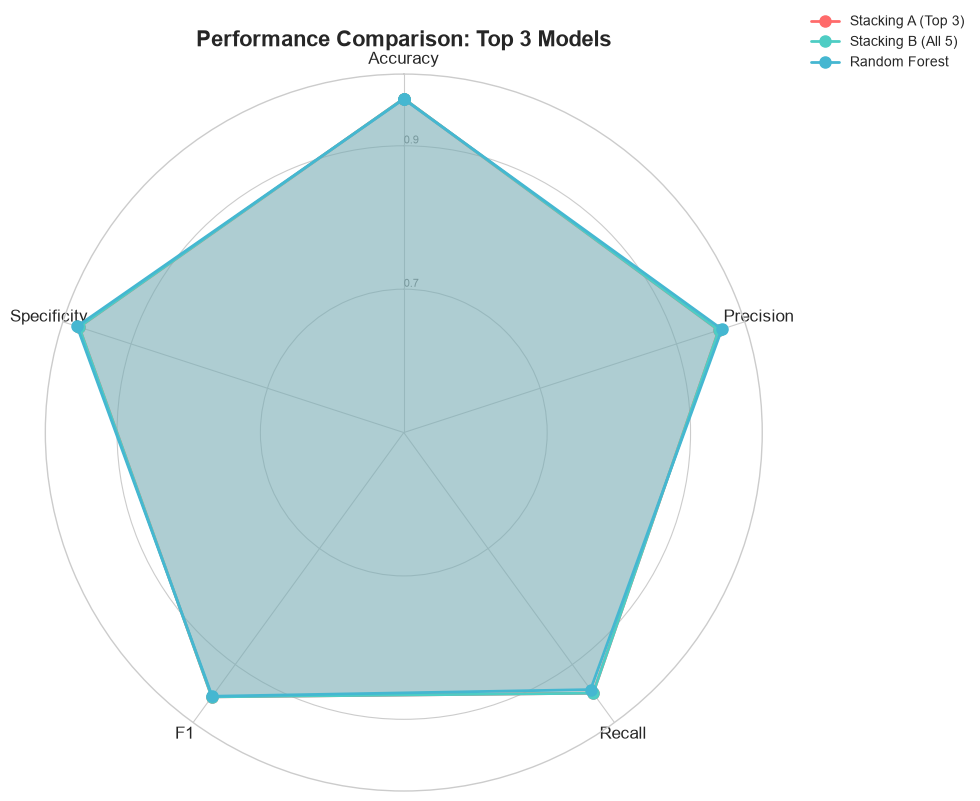

✓ Plot saved to ../results/radar_chart.png


In [5]:
from math import pi

# Select top 3 models by F1-score
top_models = df.nlargest(3, 'F1')[['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'Specificity']].copy()

# Set up the radar chart
categories = ['Accuracy', 'Precision', 'Recall', 'F1', 'Specificity']
N = len(categories)

# Calculate angles
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Close the loop

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

# Plot each model
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for i, (_, row) in enumerate(top_models.iterrows()):
    values = row[categories].values.flatten().tolist()
    values += values[:1]  # Close the loop
    
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], 
            color=colors[i], markersize=8)
    ax.fill(angles, values, alpha=0.25, color=colors[i])

# Add labels
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, size=12)
ax.set_rlabel_position(0)
plt.yticks([0.5, 0.7, 0.9], ["0.5", "0.7", "0.9"], color="grey", size=8)
plt.ylim(0.5, 1.0)

plt.title('Performance Comparison: Top 3 Models', size=16, fontweight='bold', pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()

plt.savefig('../results/radar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved to ../results/radar_chart.png")

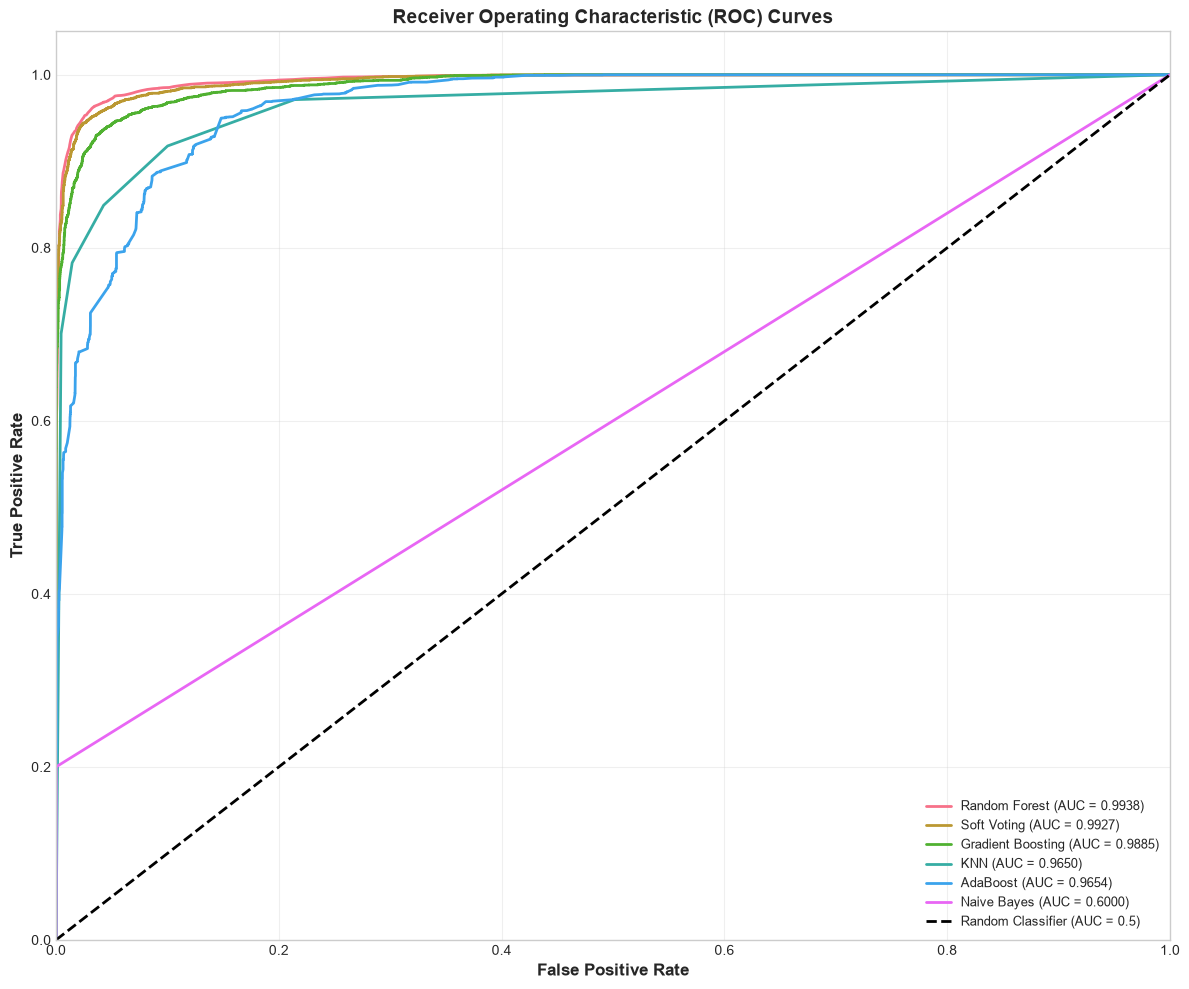

✓ Plot saved to ../results/roc_curves.png


In [6]:
# Load test data
X_test = np.load("../dataset/X_test.npy")
y_test = np.load("../dataset/y_test.npy")

plt.figure(figsize=(12, 10))

# Plot ROC curve for each model that supports probabilities
models_with_auc = df[df['AUC'] != 'N/A']

for _, row in models_with_auc.iterrows():
    model_name = row['Model']
    model_path = f"../models/{model_name.replace(' ', '_').replace('(Top_3)', '').replace('(All_5)', '').strip('_')}.pkl"
    
    if os.path.exists(model_path):
        model = joblib.load(model_path)
        
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            roc_auc = auc(fpr, tpr)
            
            plt.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {roc_auc:.4f})')

# Plot diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curves', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('../results/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved to ../results/roc_curves.png")

Generating confusion matrix for best model: Stacking A (Top 3)


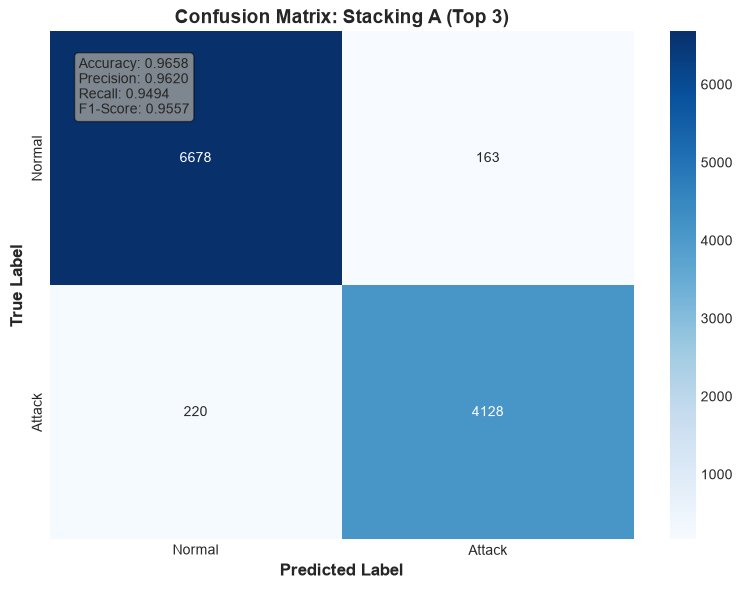

✓ Plot saved to ../results/confusion_matrix.png


In [8]:
# Get best model name from the table
best_model_name = df.loc[df['F1'].idxmax(), 'Model']
print(f"Generating confusion matrix for best model: {best_model_name}")

# Map the exact table names to the exact filenames on your computer
model_file_map = {
    "Random Forest": "Random_Forest.pkl",
    "AdaBoost": "AdaBoost.pkl",
    "Gradient Boosting": "Gradient_Boosting.pkl",
    "KNN": "KNN.pkl",
    "Naive Bayes": "Naive_Bayes.pkl",
    "Hard Voting": "hard_voting.pkl",
    "Soft Voting": "soft_voting.pkl",
    "Stacking A (Top 3)": "stacking.pkl",
    "Stacking B (All 5)": "stacking_all.pkl"
}

# Get the correct filename
filename = model_file_map.get(best_model_name)
model_path = f"../models/{filename}"

# Load the model
model = joblib.load(model_path)

# Make predictions
y_pred = model.predict(X_test)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])

plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title(f'Confusion Matrix: {best_model_name}', fontsize=14, fontweight='bold')

# Add metrics as text
tn, fp, fn, tp = cm.ravel()
metrics_text = f"Accuracy: {(tp+tn)/(tp+tn+fp+fn):.4f}\n"
metrics_text += f"Precision: {tp/(tp+fp):.4f}\n"
metrics_text += f"Recall: {tp/(tp+fn):.4f}\n"
metrics_text += f"F1-Score: {2*tp/(2*tp+fp+fn):.4f}"

plt.text(0.05, 0.95, metrics_text, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../results/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved to ../results/confusion_matrix.png")

In [9]:
# Create a formatted summary table
summary = df[['Model', 'F1', 'AUC', 'FPR', 'Size (MB)', 'Time/pkt (ms)']].copy()

# Highlight best values in green
def highlight_best(col):
    if col.name in ['F1', 'AUC']:
        is_max = col == col.max()
        return ['background-color: lightgreen' if v else '' for v in is_max]
    elif col.name in ['FPR', 'Size (MB)', 'Time/pkt (ms)']:
        is_min = col == col.min()
        return ['background-color: lightgreen' if v else '' for v in is_min]
    return [''] * len(col)

# Apply styling
styled_summary = summary.style.apply(highlight_best)

print("FINAL SUMMARY TABLE (Green = Best Performance/Efficiency)")
display(styled_summary)

# Save to CSV for your thesis document
summary.to_csv("../results/final_summary.csv", index=False)
print("\n✓ Summary saved to ../results/final_summary.csv")

FINAL SUMMARY TABLE (Green = Best Performance/Efficiency)


,Model,F1,AUC,FPR,Size (MB),Time/pkt (ms)
0,Stacking A (Top 3),0.955700,0.994000,0.023800,40.820000,0.052600
1,Stacking B (All 5),0.955700,0.993900,0.023800,105.030000,0.513800
2,Random Forest,0.954700,0.993800,0.020800,40.650000,0.013700
3,Soft Voting,0.952800,0.992700,0.024000,40.810000,0.091700
4,Hard Voting,0.949500,nan,0.024900,104.980000,0.416200
5,Gradient Boosting,0.935500,0.988500,0.037300,0.130000,0.004400
6,KNN,0.886200,0.965000,0.042700,64.200000,0.386100
7,AdaBoost,0.861000,0.965400,0.077600,0.030000,0.060500
8,Naive Bayes,0.301800,0.600000,0.000100,0.010000,0.007500



✓ Summary saved to ../results/final_summary.csv
